# Run IMC

In [1]:
import os
import time
import gzip
import pickle
import warnings

%matplotlib inline
import matplotlib.pyplot as plt

import numpy as np

from tqdm import TqdmSynchronisationWarning
warnings.simplefilter("ignore", TqdmSynchronisationWarning)

In [15]:
PATH_ROOT = "/Users/sijianfan/projects/BiSSGL"
PATH_DATA = os.path.join(PATH_ROOT, "datasets/realAnalysis/cdataset/cv_data")

PATH_OUTPUT = os.path.join(PATH_ROOT, "outputs/results/realAnalysis/cdataset/separate")
if not os.path.isdir(PATH_OUTPUT):
    os.makedirs(PATH_OUTPUT)

PATH_ARCHIVE = os.path.join(PATH_OUTPUT, "archived")
if not os.path.isdir(PATH_ARCHIVE):
    os.makedirs(PATH_ARCHIVE)

In [16]:
filename_staged = os.path.join(PATH_DATA, "staged_dataset.gz")

filenames = {"input": "staged_dataset.gz", "output": "results_imc_comb.gz"}

In [17]:
filename_input = os.path.join(PATH_DATA, filenames["input"])

filename_output = os.path.join(PATH_OUTPUT, filenames["output"])

if os.path.exists(filename_output):
    mdttm = time.strftime("%Y%m%d_%H%M%S")
    os.rename(
        filename_output,
        os.path.join(PATH_ARCHIVE, "%s%s" % (mdttm, filenames["output"])),
    )

In [5]:
from sgimc.utils import mc_split

In [6]:
from sgimc.utils import get_submatrix

In [7]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sgimc.utils import sparsify_with_mask


def mc_get_scores(R_true, R_prob):
    R_pred = np.where(R_prob.data > 0.5, 1, -1)

    # compute the confusion matrix for ±1 labels (`-1` is negative)
    ii, jj = ((R_pred + 1) // 2).astype(int), ((R_true.data + 1) // 2).astype(int)
    cnfsn = confusion_matrix(y_true=jj, y_pred=ii)

    return {
        "tn": cnfsn[0, 0],
        "fn": cnfsn[1, 0],
        "fp": cnfsn[0, 1],
        "tp": cnfsn[1, 1],
        "auc": roc_auc_score(R_true.data, R_prob.data),
    }


def combine_with_identity(X, return_sparse=True):
    """Concatenates X with the identity matrix on the right."""

    assert X.ndim == 2, "Input matrix should have ndim = 2"

    X_add = np.eye(X.shape[0])
    X_comb = np.concatenate((X.toarray(), X_add), axis=1)

    if return_sparse:
        X_comb = sparsify_with_mask(X_comb, X_comb != 0)

    return X_comb

In [8]:
import numpy as np


def get_metrics(real_score, predict_score):
    sorted_predict_score = np.array(
        sorted(list(set(np.array(predict_score).flatten())))
    )
    sorted_predict_score_num = len(sorted_predict_score)
    thresholds = sorted_predict_score[
        np.int32(sorted_predict_score_num * np.arange(1, 1000) / 1000)
    ]
    thresholds = np.mat(thresholds)
    thresholds_num = thresholds.shape[1]

    predict_score_matrix = np.tile(predict_score, (thresholds_num, 1))
    negative_index = np.where(predict_score_matrix < thresholds.T)
    positive_index = np.where(predict_score_matrix >= thresholds.T)
    predict_score_matrix[negative_index] = 0
    predict_score_matrix[positive_index] = 1
    TP = predict_score_matrix.dot(real_score.T)
    FP = predict_score_matrix.sum(axis=1) - TP
    FN = real_score.sum() - TP
    TN = len(real_score.T) - TP - FP - FN

    fpr = FP / (FP + TN)
    tpr = TP / (TP + FN)
    ROC_dot_matrix = np.mat(sorted(np.column_stack((fpr, tpr)).tolist())).T
    ROC_dot_matrix.T[0] = [0, 0]
    ROC_dot_matrix = np.c_[ROC_dot_matrix, [1, 1]]
    x_ROC = ROC_dot_matrix[0].T
    y_ROC = ROC_dot_matrix[1].T
    auc = 0.5 * (x_ROC[1:] - x_ROC[:-1]).T * (y_ROC[:-1] + y_ROC[1:])

    recall_list = tpr
    precision_list = TP / (TP + FP)
    PR_dot_matrix = np.mat(
        sorted(np.column_stack((recall_list, precision_list)).tolist())
    ).T
    PR_dot_matrix.T[0] = [0, 1]
    PR_dot_matrix = np.c_[PR_dot_matrix, [1, 0]]
    x_PR = PR_dot_matrix[0].T
    y_PR = PR_dot_matrix[1].T
    aupr = 0.5 * (x_PR[1:] - x_PR[:-1]).T * (y_PR[:-1] + y_PR[1:])

    f1_score_list = 2 * TP / (len(real_score.T) + TP - TN)
    accuracy_list = (TP + TN) / len(real_score.T)
    specificity_list = TN / (TN + FP)

    max_index = np.argmax(f1_score_list)
    f1_score = f1_score_list[max_index]
    accuracy = accuracy_list[max_index]
    specificity = specificity_list[max_index]
    recall = recall_list[max_index]
    precision = precision_list[max_index]
    return [aupr[0, 0], auc[0, 0], f1_score, accuracy, recall, specificity, precision]

In [9]:
random_state = np.random.RandomState(0x0BADCAFE)

In [10]:
from sgimc.utils import load, save

U, V, Y = load(filename_input)

In [11]:
U = combine_with_identity(U)
V = combine_with_identity(V)

In [24]:
dvlp_size, test_size = 0.9, 0.1

ind_dvlp, ind_test = next(
    mc_split(
        Y,
        n_splits=1,
        random_state=random_state,
        train_size=dvlp_size,
        test_size=test_size,
    )
)

Y_test = get_submatrix(Y, ind_test)

In [41]:
from sklearn.model_selection import ParameterGrid

grid_dataset = ParameterGrid(
    {
        "train_size": np.arange(0.1, 0.9, 0.1),
        # "train_size": [0.89],
        "n_splits": [10],
    }
)

grid_model = ParameterGrid(
    {
        "C_lasso": [0.0],
        "C_group": [0.0],
        "C_ridge": [1.0],
        "lamb": [1e-4],
        "rank": [50],
    }
)

In [26]:
from sgimc import SparseGroupIMCClassifier

In [42]:
from tqdm import tqdm
from sklearn.model_selection import ShuffleSplit, KFold
from sklearn.model_selection import train_test_split


results = []
for par_dtst in tqdm(grid_dataset):
    # prepare the train dataset: take the specified share from the beginnig of the index array
    ind_train_all, _ = train_test_split(
        ind_dvlp,
        shuffle=False,
        random_state=random_state,
        test_size=(1 - (par_dtst["train_size"] / dvlp_size)),
    )

    # Run the experiment: the model
    for par_mdl in grid_model:  # tqdm.tqdm(, desc="cv %02d" % (cv,))
        # set up the model
        C_lasso, C_group, C_ridge = (
            par_mdl["C_lasso"],
            par_mdl["C_group"],
            par_mdl["C_ridge"],
        )
        lamb = par_mdl["lamb"]
        imc = SparseGroupIMCClassifier(
            par_mdl["rank"],
            n_threads=-1,
            random_state=42,
            C_lasso=C_lasso,
            C_group=C_group,
            C_ridge=C_ridge,
        )

        # fit on the whole development dataset
        Y_train = get_submatrix(Y, ind_train_all)
        imc.fit(U, V, Y_train, sample_weight=np.ones(Y_train.nnz) / lamb)

        # get the score
        prob_full = imc.predict_proba(U, V)
        prob_test = get_submatrix(prob_full, ind_test)
        # scores_test = mc_get_scores(Y_test, prob_test)
        scores_test = get_metrics((Y_test.data + 1) / 2, prob_test.data)

        # run the k-fold CV
        # splt = ShuffleSplit(**par_dtst, random_state=random_state)
        splt = KFold(par_dtst["n_splits"], shuffle=True, random_state=random_state)
        for cv, (ind_train, ind_valid) in enumerate(splt.split(ind_train_all)):

            # prepare the train and test indices
            ind_train, ind_valid = ind_train_all[ind_train], ind_train_all[ind_valid]
            Y_train = get_submatrix(Y, ind_train)
            Y_valid = get_submatrix(Y, ind_valid)

            # fit the model
            imc = SparseGroupIMCClassifier(
                par_mdl["rank"],
                n_threads=-1,
                random_state=42,
                C_lasso=C_lasso,
                C_group=C_group,
                C_ridge=C_ridge,
            )
            imc.fit(U, V, Y_train, sample_weight=np.ones(Y_train.nnz) / lamb)

            # compute the class probabilities
            prob_full = imc.predict_proba(U, V)  # uses own copies of W, H
            prob_valid = get_submatrix(prob_full, ind_valid)

            # scores_valid = mc_get_scores(Y_valid, prob_valid)
            scores_valid = get_metrics((Y_valid.data + 1) / 2, prob_valid.data)

            # record the results
            results.append(
                {
                    "train_size": par_dtst["train_size"],
                    "lamb": par_mdl["lamb"],
                    "rank": par_mdl["rank"],
                    "cv": cv,
                    "val_score": scores_valid,
                    "test_score": scores_test,
                }
            )
        # end for
    # end for
# end for

100%|██████████| 8/8 [55:46<00:00, 418.30s/it]


In [48]:
filename_output

'/Users/sijianfan/projects/BiSSGL/outputs/results/realAnalysis/cdataset/separate/results_imc_comb.gz'

In [47]:
# Save the results in a pickle
with gzip.open(filename_output, "wb+", 4) as fout:
    pickle.dump(results, fout)

---

In [46]:
results

[{'train_size': 0.1,
  'lamb': 0.0001,
  'rank': 50,
  'cv': 0,
  'val_score': [0.06616074884228247,
   0.5103397957056495,
   0.02214022140221402,
   0.9015601783060921,
   0.1111111111111111,
   0.9095684803001877,
   0.012295081967213115],
  'test_score': [0.14055316369810128,
   0.5698833876593311,
   0.13541666666666666,
   0.9814959313342994,
   0.15057915057915058,
   0.9895700457717416,
   0.12302839116719243]},
 {'train_size': 0.1,
  'lamb': 0.0001,
  'rank': 50,
  'cv': 1,
  'val_score': [0.11542926438492507,
   0.5553192746175203,
   0.027586206896551724,
   0.8952451708766717,
   0.21052631578947367,
   0.9001122334455668,
   0.014760147601476014],
  'test_score': [0.14055316369810128,
   0.5698833876593311,
   0.13541666666666666,
   0.9814959313342994,
   0.15057915057915058,
   0.9895700457717416,
   0.12302839116719243]},
 {'train_size': 0.1,
  'lamb': 0.0001,
  'rank': 50,
  'cv': 2,
  'val_score': [0.10367108736673954,
   0.54793868354702,
   0.09836065573770492,
   0

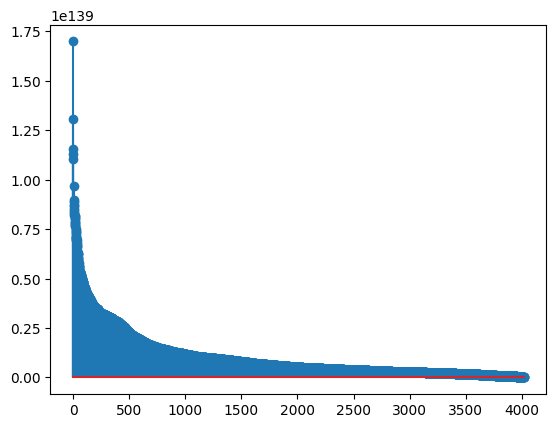

In [14]:
plt.stem(sorted(abs(imc.coef_W_).max(axis=1), reverse=True))
plt.show()

---

Run with repeated tests:

In [20]:
import numpy as np
import gzip
import pickle
from tqdm import tqdm
from sklearn.model_selection import ShuffleSplit

from sgimc import SparseGroupIMCClassifier

# -------------------------
# 0) Random generator (reproducible)
# -------------------------
rng = np.random.RandomState(0x0BADCAFE)

# -------------------------
# 1) Split once: development/test (fixed test set)
# -------------------------
dvlp_size, test_size = 0.9, 0.1

ind_dvlp, ind_test = next(
    mc_split(
        Y,
        n_splits=1,
        random_state=rng,
        train_size=dvlp_size,
        test_size=test_size,
    )
)

Y_test = get_submatrix(Y, ind_test)

# -------------------------
# 2) Hyperparameters (fixed)
# -------------------------
C_lasso = 0.0
C_group = 0.0
C_ridge = 1.0
lamb = 1e-4
rank = 50

# -------------------------
# 3) Repeated train/test setup
# -------------------------
train_sizes = np.arange(0.1, 0.9, 0.1)  # 0.1, 0.2, ..., 0.8
n_repeats = 50

results = []

for train_size in tqdm(train_sizes, desc="train_size"):

    # within train_size
    train_frac_in_dvlp = train_size / dvlp_size

    # random seed for each train_size
    splitter_seed = rng.randint(0, 2**32 - 1)

    splt = ShuffleSplit(
        n_splits=n_repeats,
        train_size=train_frac_in_dvlp,
        test_size=1.0 - train_frac_in_dvlp,
        random_state=splitter_seed,
    )

    for rep, (idx_train_rel, _) in enumerate(splt.split(ind_dvlp)):
        # the truly used train indices
        ind_train = ind_dvlp[idx_train_rel]

        # --- fit ---
        Y_train = get_submatrix(Y, ind_train)

        imc = SparseGroupIMCClassifier(
            rank,
            n_threads=-1,
            random_state=42,
            C_lasso=C_lasso,
            C_group=C_group,
            C_ridge=C_ridge,
        )
        imc.fit(U, V, Y_train, sample_weight=np.ones(Y_train.nnz) / lamb)

        # --- test score on fixed ind_test ---
        prob_full = imc.predict_proba(U, V)
        prob_test = get_submatrix(prob_full, ind_test)

        test_score = get_metrics((Y_test.data + 1) / 2, prob_test.data)

        # record
        results.append(
            {
                "train_size": float(train_size),
                "repeat": int(rep),
                "rank": int(rank),
                "lamb": float(lamb),
                "C_lasso": float(C_lasso),
                "C_group": float(C_group),
                "C_ridge": float(C_ridge),
                "splitter_seed": int(splitter_seed),
                "n_train_obs": int(Y_train.nnz),
                "test_score": test_score,
            }
        )

# -------------------------
# 4) Save results
# -------------------------
with gzip.open(filename_output, "wb+", 4) as fout:
    pickle.dump(results, fout)

train_size:   0%|          | 0/8 [00:00<?, ?it/s]

train_size: 100%|██████████| 8/8 [14:21:38<00:00, 6462.34s/it]  
